# House 4 — SNN Energy Forecasting

Clean SNN experiment using the REFIT House 4 data.

**Setup**
- 15-minute resampling
- 24 × 15-minute input window (6 hours)
- Inputs: Aggregate + 9 appliance channels + hour sin/cos + aggregate rate-of-change
- Input features standardized using **training data only**
- Target (next 15-minute Aggregate) standardized using a **separate target scaler**
- 2-layer LIF SNN
- **Continuous membrane-potential readout**, not binary spike readout
- MSE loss
- AdamW
- Early stopping with best validation checkpoint
- Final metrics reported back in Watts


In [21]:
# ============================================================
# 1. Imports
# ============================================================
!pip install -q snntorch
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [ ]:
# ============================================================
# 2. Configuration
# ============================================================

DATA_PATH = "/kaggle/input/datasets/kyleahmurphy/uk-electrical-load/House_4.csv"

WINDOW = 24          # 24 x 15 min = 6 hours
HORIZON = 1          # next 15-minute interval

BATCH_SIZE = 128
EPOCHS = 50

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

HIDDEN_1 = 32
HIDDEN_2 = 16
BETA = 0.7

PATIENCE = 7

print("Window:", WINDOW)
print("Horizon:", HORIZON)
print("Learning rate:", LEARNING_RATE)
print("Beta:", BETA)


Window: 24
Horizon: 1
Learning rate: 0.0001
Beta: 0.7


In [23]:
# ============================================================
# 3. Load and preprocess House 4
# ============================================================

df = pd.read_csv(DATA_PATH)

df["Time"] = pd.to_datetime(df["Time"])

df = (
    df
    .sort_values("Time")
    .reset_index(drop=True)
)

power_cols = [
    "Aggregate",
    "Appliance1", "Appliance2", "Appliance3",
    "Appliance4", "Appliance5", "Appliance6",
    "Appliance7", "Appliance8", "Appliance9"
]

# Keep only required columns
df = df[["Time"] + power_cols].copy()

# 15-minute average
df = (
    df
    .set_index("Time")[power_cols]
    .resample("15min")
    .mean()
    .dropna()
    .reset_index()
)

print("15-minute shape:", df.shape)
print("Time range:", df["Time"].min(), "→", df["Time"].max())


15-minute shape: (53375, 11)
Time range: 2013-10-11 10:15:00 → 2015-07-07 09:45:00


In [24]:
# ============================================================
# 4. Create time features, rate-of-change, and target
# ============================================================

hour = df["Time"].dt.hour + df["Time"].dt.minute / 60.0

df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

# Change from the previous 15-minute aggregate.
# shift(1) means this uses only past information.
df["agg_diff"] = df["Aggregate"].diff()

# First row has no previous value.
df["agg_diff"] = df["agg_diff"].fillna(0)

# Future aggregate target.
df["Target"] = df["Aggregate"].shift(-HORIZON)

df = df.dropna().reset_index(drop=True)

print("Final shape:", df.shape)


Final shape: (53374, 15)


count    53374.000000
mean       379.428953
std        321.179805
min          0.000000
50%        320.727188
75%        470.629297
90%        618.071592
95%        801.759808
99%       1630.318950
max       7814.576271
Name: Target, dtype: float64

Percentiles:
P50: 320.73 W
P75: 470.63 W
P90: 618.07 W
P95: 801.76 W
P99: 1630.32 W
Maximum: 7814.58 W


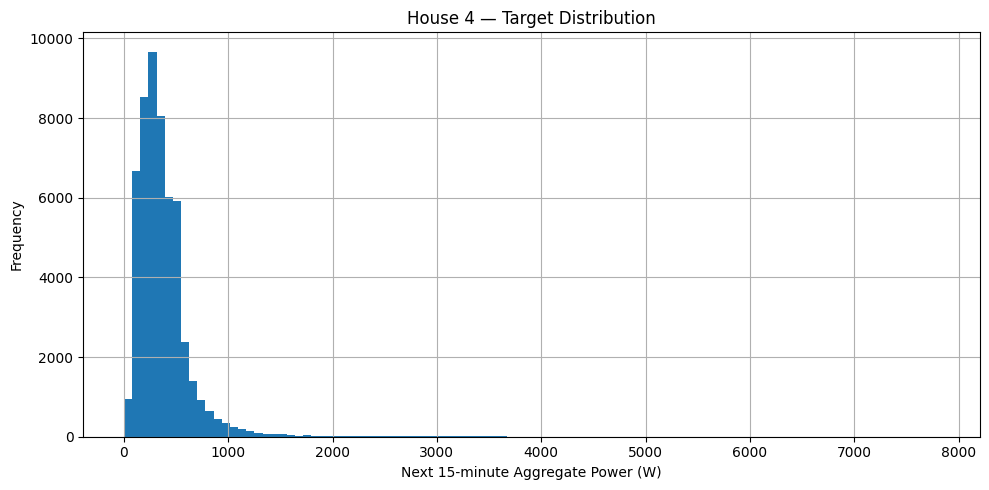

In [25]:
# ============================================================
# 5. Target distribution
# ============================================================

target = df["Target"].values

print(df["Target"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
))

print("\nPercentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"P{p}: {np.percentile(target, p):.2f} W")

print(f"Maximum: {target.max():.2f} W")

plt.figure(figsize=(10, 5))
plt.hist(target, bins=100)
plt.xlabel("Next 15-minute Aggregate Power (W)")
plt.ylabel("Frequency")
plt.title("House 4 — Target Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
# ============================================================
# 6. Chronological train / validation / test split
# ============================================================

n = len(df)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)


Train: (37361, 15)
Val:   (8006, 15)
Test:  (8007, 15)


In [27]:
# ============================================================
# 7. Feature scaling
# ============================================================

# Power/appliance input scaler
power_scaler = StandardScaler()

train_power_scaled = power_scaler.fit_transform(
    train_df[power_cols]
)

val_power_scaled = power_scaler.transform(
    val_df[power_cols]
)

test_power_scaled = power_scaler.transform(
    test_df[power_cols]
)


# Aggregate-difference scaler
diff_scaler = StandardScaler()

train_df["agg_diff_scaled"] = diff_scaler.fit_transform(
    train_df[["agg_diff"]]
).ravel()

val_df["agg_diff_scaled"] = diff_scaler.transform(
    val_df[["agg_diff"]]
).ravel()

test_df["agg_diff_scaled"] = diff_scaler.transform(
    test_df[["agg_diff"]]
).ravel()


# ------------------------------------------------------------
# IMPORTANT: separate target scaler
# ------------------------------------------------------------
# Target is the future Aggregate.
# Fit ONLY on training Aggregate values.

target_scaler = StandardScaler()

target_scaler.fit(
    train_df[["Aggregate"]]
)

print("Target mean:", target_scaler.mean_[0])
print("Target std: ", target_scaler.scale_[0])


Target mean: 386.13973728246657
Target std:  332.47918268747156


In [28]:
# ============================================================
# 8. Create temporal sequences
# ============================================================

feature_cols = [
    "Aggregate",
    "Appliance1", "Appliance2", "Appliance3",
    "Appliance4", "Appliance5", "Appliance6",
    "Appliance7", "Appliance8", "Appliance9",
    "hour_sin",
    "hour_cos",
    "agg_diff_scaled"
]

def create_sequences(power_scaled, df_split, window=24):
    X = []
    y = []

    hour_sin = df_split["hour_sin"].values
    hour_cos = df_split["hour_cos"].values
    agg_diff = df_split["agg_diff_scaled"].values

    for i in range(len(power_scaled) - window):
        sequence = np.column_stack([
            power_scaled[i:i + window],
            hour_sin[i:i + window],
            hour_cos[i:i + window],
            agg_diff[i:i + window]
        ])

        # Future Aggregate is already standardized in power_scaled[:, 0].
        target = power_scaled[i + window, 0]

        X.append(sequence)
        y.append(target)

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32).reshape(-1, 1)
    )


X_train, y_train = create_sequences(
    train_power_scaled, train_df, WINDOW
)

X_val, y_val = create_sequences(
    val_power_scaled, val_df, WINDOW
)

X_test, y_test = create_sequences(
    test_power_scaled, test_df, WINDOW
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)


X_train: (37337, 24, 13)
y_train: (37337, 1)
X_val:   (7982, 24, 13)
y_val:   (7982, 1)
X_test:  (7983, 24, 13)
y_test:  (7983, 1)


In [29]:
# ============================================================
# 9. DataLoaders
# ============================================================

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train),
        torch.tensor(y_train)
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_val),
        torch.tensor(y_val)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test),
        torch.tensor(y_test)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 292
Validation batches: 63
Test batches: 63


In [30]:
# ============================================================
# 10. SNN — continuous membrane readout
# ============================================================

class SNNForecaster(nn.Module):

    def __init__(
        self,
        input_size=13,
        hidden1=32,
        hidden2=16,
        beta=0.9
    ):
        super().__init__()

        self.fc1 = nn.Linear(
            input_size,
            hidden1
        )

        self.lif1 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc2 = nn.Linear(
            hidden1,
            hidden2
        )

        self.lif2 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        # Continuous regression output
        self.output = nn.Linear(
            hidden2,
            1
        )

    def forward(self, x):

        # x = [batch, time, features]
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        last_mem2 = None

        for t in range(x.size(1)):

            cur1 = self.fc1(
                x[:, t, :]
            )

            spk1, mem1 = self.lif1(
                cur1,
                mem1
            )

            cur2 = self.fc2(
                spk1
            )

            spk2, mem2 = self.lif2(
                cur2,
                mem2
            )

            last_mem2 = mem2

        # IMPORTANT:
        # Use the continuous membrane potential,
        # not the binary spike, for regression.
        return self.output(last_mem2)


model = SNNForecaster(
    input_size=X_train.shape[-1],
    hidden1=HIDDEN_1,
    hidden2=HIDDEN_2,
    beta=BETA
).to(DEVICE)

print(model)

print(
    "\nTrainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)


SNNForecaster(
  (fc1): Linear(in_features=13, out_features=32, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (lif2): Leaky()
  (output): Linear(in_features=16, out_features=1, bias=True)
)

Trainable parameters: 993


In [31]:
# ============================================================
# 11. Train with early stopping
# ============================================================

criterion = nn.MSELoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_state = None
best_epoch = 0
patience_counter = 0

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()

    train_total = 0.0

    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        pred = model(xb)

        loss = criterion(
            pred,
            yb
        )

        loss.backward()

        optimizer.step()

        train_total += loss.item()

    train_loss = train_total / len(train_loader)
    train_losses.append(train_loss)


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    val_total = 0.0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = model(xb)

            loss = criterion(
                pred,
                yb
            )

            val_total += loss.item()

    val_loss = val_total / len(val_loader)
    val_losses.append(val_loss)


    # --------------------------------------------------------
    # Best checkpoint
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = copy.deepcopy(
            model.state_dict()
        )

        best_epoch = epoch + 1
        patience_counter = 0

    else:

        patience_counter += 1


    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train {train_loss:.6f} | "
        f"Val {val_loss:.6f}"
    )


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch+1}"
        )

        break


# Restore best validation checkpoint
model.load_state_dict(best_state)

print(
    f"\nBest epoch: {best_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.6f}"
)


Epoch 01/50 | Train 0.951406 | Val 0.770641
Epoch 02/50 | Train 0.884854 | Val 0.737881
Epoch 03/50 | Train 0.854552 | Val 0.715202
Epoch 04/50 | Train 0.829083 | Val 0.702548
Epoch 05/50 | Train 0.812236 | Val 0.689181
Epoch 06/50 | Train 0.799464 | Val 0.680701
Epoch 07/50 | Train 0.784939 | Val 0.675015
Epoch 08/50 | Train 0.772312 | Val 0.666561
Epoch 09/50 | Train 0.764104 | Val 0.661021
Epoch 10/50 | Train 0.758948 | Val 0.657808
Epoch 11/50 | Train 0.751294 | Val 0.656319
Epoch 12/50 | Train 0.746425 | Val 0.655446
Epoch 13/50 | Train 0.743869 | Val 0.651925
Epoch 14/50 | Train 0.741814 | Val 0.647598
Epoch 15/50 | Train 0.741213 | Val 0.646732
Epoch 16/50 | Train 0.735233 | Val 0.644657
Epoch 17/50 | Train 0.731564 | Val 0.648355
Epoch 18/50 | Train 0.729906 | Val 0.643633
Epoch 19/50 | Train 0.729475 | Val 0.644156
Epoch 20/50 | Train 0.726062 | Val 0.648739
Epoch 21/50 | Train 0.726548 | Val 0.644936
Epoch 22/50 | Train 0.722971 | Val 0.644579
Epoch 23/50 | Train 0.721477 | V

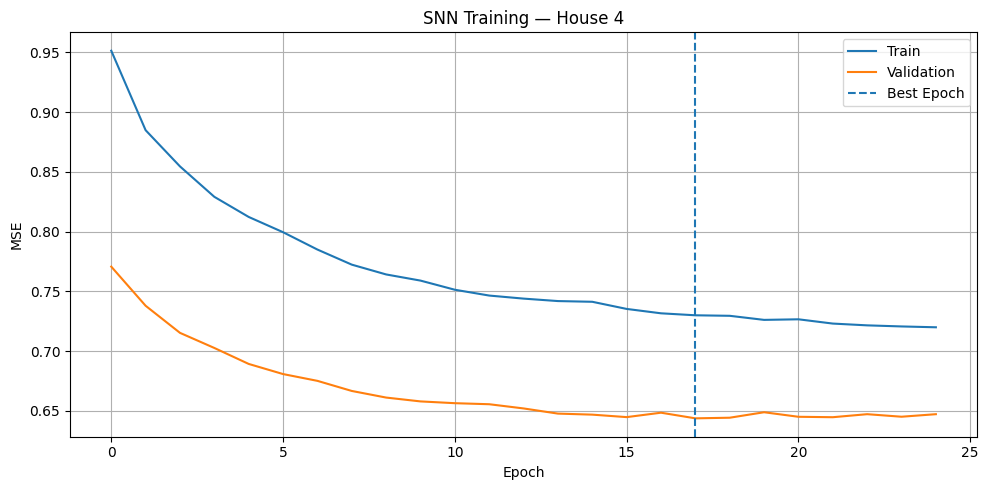

In [32]:
# ============================================================
# 12. Training / validation loss
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label="Best Epoch"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("SNN Training — House 4")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
# ============================================================
# 13. Test predictions
# ============================================================

model.eval()

pred_scaled = []
actual_scaled = []

with torch.no_grad():

    for xb, yb in test_loader:

        pred = model(
            xb.to(DEVICE)
        )

        pred_scaled.append(
            pred.cpu().numpy()
        )

        actual_scaled.append(
            yb.numpy()
        )

pred_scaled = np.concatenate(
    pred_scaled
).reshape(-1, 1)

actual_scaled = np.concatenate(
    actual_scaled
).reshape(-1, 1)


# ------------------------------------------------------------
# Convert back to actual Watts
# ------------------------------------------------------------

pred_watts = target_scaler.inverse_transform(
    pred_scaled
).ravel()

actual_watts = target_scaler.inverse_transform(
    actual_scaled
).ravel()

print("Predictions:", pred_watts.shape)


Predictions: (7983,)


In [34]:
# ============================================================
# 14. Evaluation
# ============================================================

def evaluate_power(actual, pred, name):

    actual = np.asarray(actual).ravel()
    pred = np.asarray(pred).ravel()

    mae = mean_absolute_error(
        actual,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    r2 = r2_score(
        actual,
        pred
    )

    # Top 10% actual loads
    p90 = np.percentile(
        actual,
        90
    )

    mask = actual >= p90

    peak_mae = mean_absolute_error(
        actual[mask],
        pred[mask]
    )

    peak_rmse = np.sqrt(
        mean_squared_error(
            actual[mask],
            pred[mask]
        )
    )

    peak_ratio = (
        pred.max() / actual.max()
    )

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print(f"MAE       : {mae:.2f} W")
    print(f"RMSE      : {rmse:.2f} W")
    print(f"R²        : {r2:.4f}")
    print(f"Peak MAE  : {peak_mae:.2f} W")
    print(f"Peak RMSE : {peak_rmse:.2f} W")
    print(f"Actual max: {actual.max():.2f} W")
    print(f"Pred max  : {pred.max():.2f} W")
    print(f"Peak ratio: {peak_ratio:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Peak_MAE": peak_mae,
        "Peak_RMSE": peak_rmse,
        "Actual_Max": actual.max(),
        "Pred_Max": pred.max(),
        "Peak_Ratio": peak_ratio
    }


result = evaluate_power(
    actual_watts,
    pred_watts,
    "SNN — House 4"
)



SNN — House 4
MAE       : 149.98 W
RMSE      : 245.36 W
R²        : 0.1885
Peak MAE  : 398.06 W
Peak RMSE : 617.02 W
Actual max: 4569.04 W
Pred max  : 1648.79 W
Peak ratio: 0.3609


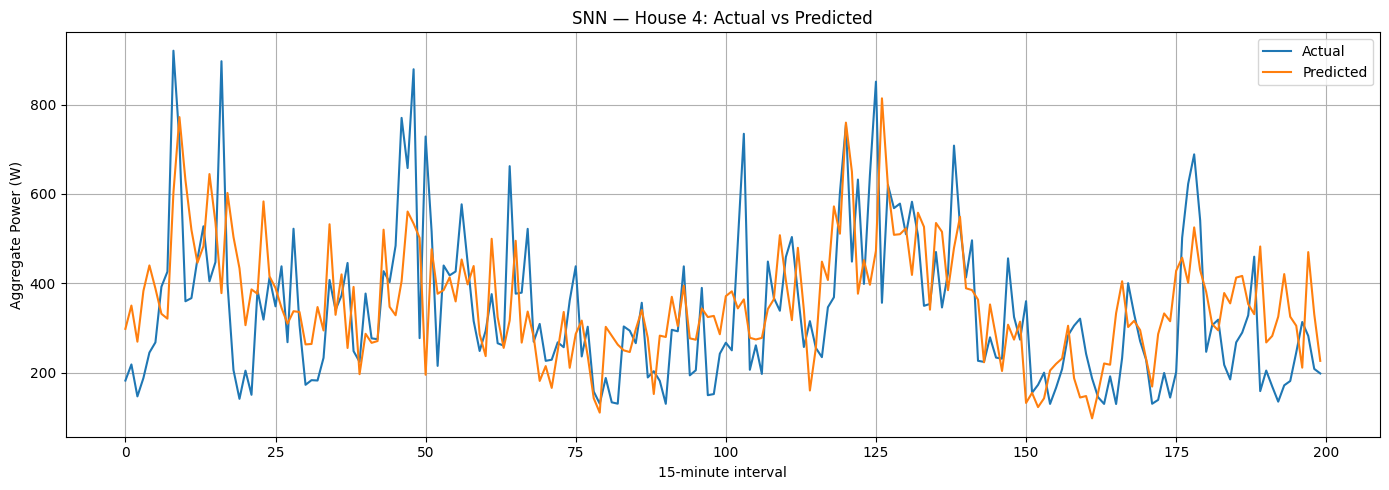

In [35]:
# ============================================================
# 15. Actual vs predicted — first 200 test intervals
# ============================================================

points = min(
    200,
    len(actual_watts)
)

plt.figure(figsize=(14, 5))

plt.plot(
    actual_watts[:points],
    label="Actual"
)

plt.plot(
    pred_watts[:points],
    label="Predicted"
)

plt.xlabel("15-minute interval")
plt.ylabel("Aggregate Power (W)")
plt.title("SNN — House 4: Actual vs Predicted")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [36]:
# ============================================================
# 16. Peak diagnostic
# ============================================================

p90 = np.percentile(
    actual_watts,
    90
)

peak_mask = actual_watts >= p90

print("P90 threshold:", f"{p90:.2f} W")
print(
    "Actual mean at P90+:",
    f"{actual_watts[peak_mask].mean():.2f} W"
)
print(
    "Predicted mean at P90+:",
    f"{pred_watts[peak_mask].mean():.2f} W"
)

print(
    "Actual maximum:",
    f"{actual_watts.max():.2f} W"
)

print(
    "Predicted maximum:",
    f"{pred_watts.max():.2f} W"
)


P90 threshold: 571.53 W
Actual mean at P90+: 905.02 W
Predicted mean at P90+: 535.20 W
Actual maximum: 4569.04 W
Predicted maximum: 1648.79 W


In [37]:
# Find actual and predicted maximums
actual_max_idx = np.argmax(actual_watts)
pred_max_idx = np.argmax(pred_watts)

print("Actual max:")
print(f"  Value: {actual_watts[actual_max_idx]:.2f} W")
print(f"  Index: {actual_max_idx}")
print(f"  Prediction at same index: {pred_watts[actual_max_idx]:.2f} W")

print("\nPredicted max:")
print(f"  Value: {pred_watts[pred_max_idx]:.2f} W")
print(f"  Index: {pred_max_idx}")
print(f"  Actual at same index: {actual_watts[pred_max_idx]:.2f} W")

Actual max:
  Value: 4569.04 W
  Index: 5374
  Prediction at same index: 1184.25 W

Predicted max:
  Value: 1648.79 W
  Index: 5375
  Actual at same index: 3179.55 W


In [38]:
# Show ±10 intervals around the actual maximum
start = max(0, actual_max_idx - 10)
end = min(len(actual_watts), actual_max_idx + 11)

print("\nAround actual maximum:")
for i in range(start, end):
    print(
        f"{i:4d}: "
        f"Actual = {actual_watts[i]:8.2f} W | "
        f"Predicted = {pred_watts[i]:8.2f} W"
    )


Around actual maximum:
5364: Actual =   108.92 W | Predicted =   397.80 W
5365: Actual =    83.07 W | Predicted =   356.98 W
5366: Actual =   164.96 W | Predicted =   347.45 W
5367: Actual =   100.18 W | Predicted =   358.64 W
5368: Actual =   223.52 W | Predicted =   310.38 W
5369: Actual =   369.48 W | Predicted =   416.93 W
5370: Actual =   353.75 W | Predicted =   443.72 W
5371: Actual =   333.96 W | Predicted =   237.59 W
5372: Actual =   265.32 W | Predicted =   222.90 W
5373: Actual =  3630.75 W | Predicted =   346.80 W
5374: Actual =  4569.04 W | Predicted =  1184.25 W
5375: Actual =  3179.55 W | Predicted =  1648.79 W
5376: Actual =   362.17 W | Predicted =  1477.58 W
5377: Actual =   124.41 W | Predicted =   988.19 W
5378: Actual =   498.53 W | Predicted =   703.15 W
5379: Actual =  1122.74 W | Predicted =   791.47 W
5380: Actual =  1656.86 W | Predicted =  1145.12 W
5381: Actual =   711.53 W | Predicted =  1380.15 W
5382: Actual =  2588.69 W | Predicted =   616.55 W
5383: A

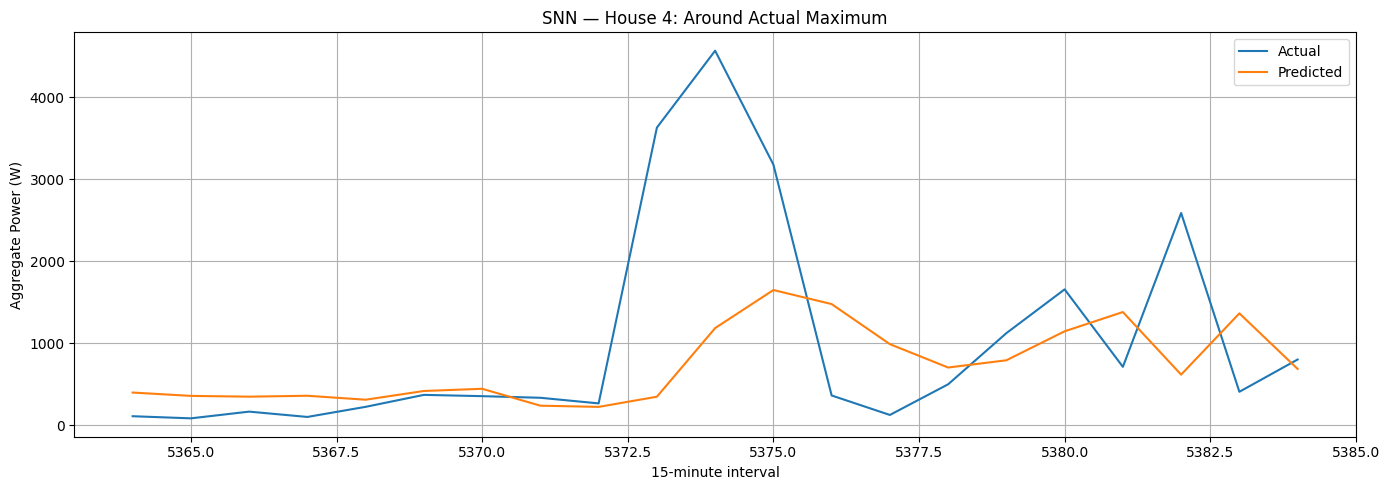

In [39]:
plt.figure(figsize=(14, 5))

plt.plot(
    range(start, end),
    actual_watts[start:end],
    label="Actual"
)

plt.plot(
    range(start, end),
    pred_watts[start:end],
    label="Predicted"
)

plt.xlabel("15-minute interval")
plt.ylabel("Aggregate Power (W)")
plt.title("SNN — House 4: Around Actual Maximum")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Next experiment

Do **not** change the architecture immediately if this run is poor.

Use this run to determine:

- If peaks are still badly underestimated → try a peak-aware loss.
- If validation loss starts rising → early stopping should already select the best epoch.
- If the model follows the signal but lacks long-term context → test `WINDOW = 48` and `WINDOW = 96`.
- If this works substantially better on House 4 → keep House 4 and continue SNN-specific experiments.

The important thing is that all predictions are converted back to **Watts** before evaluation.


In [40]:
# Inspect features around the biggest actual spike
for i in range(5370, 5375):
    print(f"\nIndex {i}")
    print("Aggregate:", actual_watts[i])
    print("Features:", X_test[i])


Index 5370
Aggregate: 353.74615
Features: [[-4.60484684e-01  2.26866245e+00 -9.39278603e-01  8.90494347e-01
  -5.36223128e-02 -8.56535137e-02 -7.14717329e-01 -7.90599525e-01
  -1.37407988e-01 -1.64914489e-01  2.58819044e-01  9.65925813e-01
   4.25224662e-01]
 [-9.50971425e-01 -5.60865104e-01 -9.39278603e-01 -7.73513794e-01
  -5.36223128e-02 -8.56535137e-02 -7.14717329e-01 -7.90599525e-01
  -1.37407988e-01 -1.64914489e-01  3.21439475e-01  9.46930110e-01
  -4.89842623e-01]
 [-4.27767247e-01 -5.60865104e-01  1.23942721e+00 -8.48493755e-01
  -5.36223128e-02 -8.56535137e-02 -7.14717329e-01 -7.90599525e-01
  -1.37407988e-01 -1.64914489e-01  3.82683426e-01  9.23879504e-01
   5.22578597e-01]
 [ 1.08875163e-01 -5.60865104e-01  1.32540965e+00  1.17513192e+00
  -5.36223128e-02 -8.56535137e-02 -7.14717329e-01 -7.90599525e-01
  -1.37407988e-01 -1.64914489e-01  4.42288697e-01  8.96872759e-01
   5.36000013e-01]
 [-4.24321890e-01 -5.60865104e-01  1.16799808e+00 -8.48493755e-01
  -5.36223128e-02 -8.56